# makemore MLP
following the lines of paper: https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

In [143]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [144]:
# read in all the words
words = open('../name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [145]:
len(words)

32033

In [146]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [147]:

# build the dataset
block_size = 3  # context length: how many characters do we take to predict the next one
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]    # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, Y.shape)

torch.Size([228146, 3]) torch.Size([228146])


In [148]:
C = torch.randn((27, 2))
emb = C[X]

In [149]:
# torch index examples
print(F.one_hot(torch.tensor(5), num_classes=27).float() @ C)
print(C[5])
print(C[[5, 6, 7]])
print(C[torch.tensor([5, 6 ,7])])
print(C[torch.tensor([[5, 6 ,7], [5, 6, 7]])])

# C[X[x, y]] == C[X][x, y]
print(C[X].shape)
print(X[13, 2])
print(C[X][13, 2])
print(C[1])
print(C[X[13, 2]])

tensor([ 0.7867, -0.3448])
tensor([ 0.7867, -0.3448])
tensor([[ 0.7867, -0.3448],
        [ 0.8467,  1.0273],
        [-1.1483,  0.9607]])
tensor([[ 0.7867, -0.3448],
        [ 0.8467,  1.0273],
        [-1.1483,  0.9607]])
tensor([[[ 0.7867, -0.3448],
         [ 0.8467,  1.0273],
         [-1.1483,  0.9607]],

        [[ 0.7867, -0.3448],
         [ 0.8467,  1.0273],
         [-1.1483,  0.9607]]])
torch.Size([228146, 3, 2])
tensor(1)
tensor([ 1.2373, -0.7981])
tensor([ 1.2373, -0.7981])
tensor([ 1.2373, -0.7981])


In [150]:
# 6: each character is of 2 dims, we are using 3 preceding characters
#    to predict the next one, so the inputs is of 3 * 2 = 6 dims
# 100: the size of the hidden layer
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
# emb @ W1 + b1
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [151]:
# notes: how to acheive `emb @ W1 + b1`
print(emb.shape)
print(W1.shape)
print(b1.shape)

# naive approach
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)
# equivalently
# torch.cat(torch.unbind(emb, dim=1), dim=1)

# introduce `view` which does not create new storage for the tensor
# a = emb.view(32, 6)
# emb.view(32, 6) == torch.cat(torch.unbind(emb, dim=1), dim=1)
# equivalently
# b = emb.view(-1, 6)



torch.Size([228146, 3, 2])
torch.Size([6, 100])
torch.Size([100])


In [152]:
# W2 = torch.randn((100, 27))
# b2 = torch.randn(27)
# logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = - prob[torch.arange(32), Y].log().mean()

In [153]:
# ------------------- now made respectable ------------------
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [154]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True


In [155]:
sum(p.nelement() for p in parameters)

3481

In [156]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [157]:
lri = []
lossi = []

for i in range(1000):
    # minibatch construction
    ix = torch.randint(0, X.shape[0], (32,))    # mini batch size = 32

    # forward pass 
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)   # (32, 100)
    logits = h @ W2 + b2    # (32, 27)
    # why use F.cross_entropy not handrolled?
    # 1. forwrd and backward pass more efficient;
    #    no intermediate tensors like counts, prob, etc.
    # 2. mathmatically more behaved;
    #    e.x. [-100, 3, 5, 100].exp() -> [...,...,..., nan]
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())


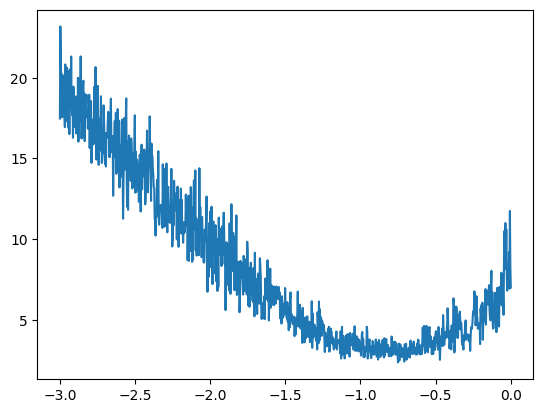

In [158]:
plt.plot(lri, lossi)